<a href="https://colab.research.google.com/github/mwetmore05/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maggie Wetmor

**Date:** 9/06/2026

#1-1

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
airbnb_df = pd.read_csv('/content/airbnb_hw.csv') #all prices in same format
airbnb_df['Price'].head()


print("airbnb_df.shape:") #looking at number of rows and columns
print(airbnb_df.shape, '\n')


print("airbnb_df.dtypes:") # looking at columns type, because an unexpected dtype can flad a variable that needs cleaning
print(airbnb_df.dtypes, '\n')


airbnb_df['Price'] = airbnb_df['Price'].str.replace("$", "", regex=False) #remove $ sign
airbnb_df['Price'] = airbnb_df['Price'].str.replace(",", "", regex=False ) #remove commas sign




airbnb_df.shape:
(30478, 13) 

airbnb_df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 



In [7]:
#I see that the Price variable is an object, I need to tranform it into an int, since the price variable is a whole numbes


airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors='coerce')
airbnb_df['Price'].dtype

print("Total missing values", airbnb_df['Price'].isna().sum()) #checking total missing values
#making units clear in column name for visual purposes
airbnb_df.rename(columns={'Price' :'Price in US dollars'})
airbnb_df['Price'].head()
airbnb_df['Price'].sort_values() #checking and sorting values ascending order


Total missing values 0


,Price
30087,10
3120,10
19275,10
9793,20
25139,20
...,...
15633,5000
2405,5999
17900,6500
4002,8000


#1-2

In [9]:

import pandas as pd
import numpy as np

#opening the minnsota police of force dataset
police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

print("police_df.shape:") #looking at the number of rows and columns
print(police_df.shape, '\n')

print("police_df.dtypes:") #looking at the column types because an unexpected dtype can flag a variable that needs cleaning
print(police_df.dtypes, '\n')

print("Unique subject_injury values:")
print(police_df['subject_injury'].unique(), '\n') # examing the possible values of subject_injury before cleaning, allowing me to identify the valid categories and any missing values

print("Counts of subject_injury values:") #including NaN in  counts bc the question specifically asks about missing data
print(police_df['subject_injury'].value_counts(dropna=False), '\n')

police_df['subject_injury_nan'] = police_df['subject_injury'].isnull() # creating another record indicating subject_injury is missing, NaN means that injury status was not recorded or is unknown

print("Total missing subject_injury values:") #finding  total number of missing subject_injury values
print(police_df['subject_injury_nan'].sum(), '\n')

missing_proportion = ( #calculating proportions of missing
    police_df['subject_injury_nan'].sum()
    / len(police_df))

print("Proportion missing:", missing_proportion)
print("Percent missing:", missing_proportion * 100)

# Keeping missing values separate because NaN does not mean that no injury occurred
police_df['subject_injury_clean'] = police_df['subject_injury'].fillna('Missing')

# Cross-tabulation of injury status and force type
injury_force_table = pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury_clean']
)

injury_force_table


police_df.shape:
(12925, 13) 

police_df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

Unique subject_injury values:
[nan 'No' 'Yes'] 

Counts of subject_injury values:
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Total missing subject_injury values:
9848 

Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892


subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


ABout 76.2% of the subject injury values are missing. THe Missig injury data is especially common for bodily foce, chemica irritant, improvised weapon, less lethal, max restraint technique, and taser. The missingness differs by force type so it does not appear random. This tells us something about the missingness of the data and proves it to be important and to always analyze missingness in a dataset before disgarding it.

#2

In [13]:

import matplotlib.pyplot as plt

shark = pd.read_excel('/content/GSAF5.xls') #open excel file

shark.head()

shark = shark.drop( #drop columns with NaN data, after seeing almos tno data upon further investigation
    columns=[
        'pdf',
        'href formula',
        'href',
        'Case Number',
        'Case Number.1',
        'original order',
        'Unnamed: 21',
        'Unnamed: 22'
    ]
)



count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64


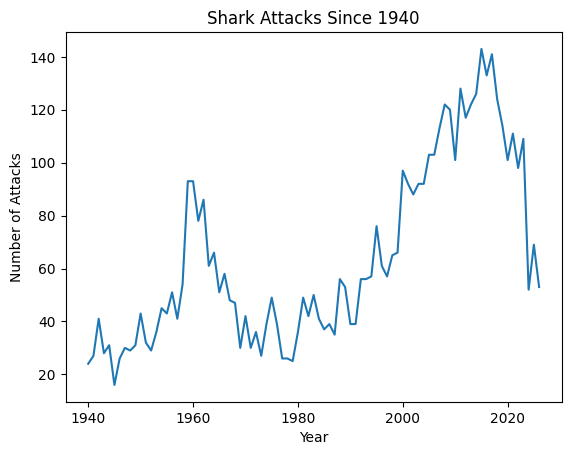

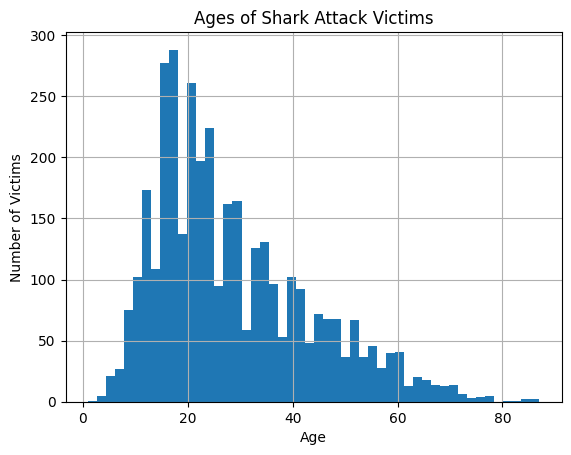

Proportion male: 0.8571707317073171
Proportion unprovoked: 0.7459236695932628


In [14]:
print(shark['Year'].describe()) #investoigating at the Year variable

shark['Year'] = pd.to_numeric(shark['Year'], errors='coerce') #making 0 as missing for year varaible
shark['Year'] = shark['Year'].replace(0, np.nan)

shark = shark[shark['Year'] >= 1940].copy()  #focus on attacks since 1940

attacks_per_year = shark['Year'].value_counts().sort_index() #looking at the number of attacks per year
attacks_per_year.plot()

plt.xlabel('Year') #making plot to show relationship
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks Since 1940')
plt.show()

shark['Age'] = pd.to_numeric(shark['Age'], errors='coerce') #clean age varaible

shark['Age'].hist(bins=50) #using hisotgram plot to show age varibale
plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Ages of Shark Attack Victims')
plt.show()

shark['Sex'] = shark['Sex'].str.strip().str.upper() #clean sex varaible

male_proportion = ( #calculating the proportion of recorded victims who are male
    (shark['Sex'] == 'M').sum()
    / shark['Sex'].isin(['M', 'F']).sum()
)
print("Proportion male:", male_proportion)

shark['Type'] = shark['Type'].str.strip().str.lower() #clean type varaible
shark['Type'] = shark['Type'].replace({
    'provoked': 'Provoked',
    'unprovoked': 'Unprovoked'
})

shark.loc[  #changing missing values for type into Unknown, instead of other words
    ~shark['Type'].isin(['Provoked', 'Unprovoked']),
    'Type'
] = 'Unknown'

unprovoked_proportion = ( #calculating proportion of attacks that were unprovoked
    (shark['Type'] == 'Unprovoked').sum()
    / len(shark)
)

print("Proportion unprovoked:", unprovoked_proportion)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 13389d4b980e6c51a8c465ada19020a0b0915132
- **AI tool and model used:** Chat GPT-5.6 Sol

### *Prompts used


1-1. Is there anything I should do to edit and enhance my code?

1-2. Please give me suggestions how to update this?

2. Is this the best way to code this / is there any improvements i should make?

### *AI-proposed changes


1.1. Your code is strong overall. I would make a few important edits:

 - 1. Your Airbnb rename does not save because it needs inplace=True or reassignment.
 - 2. Keep Price as numeric/float if there are missing values rather than converting to a regular integer.
 - 3. Check whether errors='coerce' created any new missing values.
 - 4. Use describe() to identify unusual prices.

1.2. Suggestions:
 - 1. Remove import numpy as np because NumPy is not used.
  - 2. Change .isnull() to .isna() for consistency with your other missing-value checks. Both work, though
   - 3. Round the missing percentage: print("Percent missing:", round(missing_proportion * 100, 2), "%")
   - 4. Add a row-percentage cross-tabulation to compare missingness across force types: pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury_clean'],
    normalize='index') .round(3) * 100
2. Your overall approach is correct, but I would make these five improvements:
 - 1. Import the packages you use:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 - 2. Drop genuinely empty columns automatically. This avoids a KeyError if an expected column name is missing: shark = shark.dropna(axis=1, how='all') If you also want to remove the link and identification columns, use errors='ignore': shark = shark.drop(
    columns=[
        'pdf',
        'href formula',
        'href',
        'Case Number',
        'Case Number.1',
        'original order'
    ],
    errors='ignore'
)
 - 3. Convert Year before using describe(). Currently, you describe the uncleaned variable: shark['Year'] = pd.to_numeric(shark['Year'], errors='coerce') shark['Year'] = shark['Year'].replace(0, np.nan) print(shark['Year'].describe()) shark = shark[shark['Year'] >= 1940].copy()
 - 4. Add a moving average to make the trend easier to interpret: attacks_per_year = shark['Year'].value_counts().sort_index()attacks_per_year.plot(label='Annual attacks', alpha=0.6) attacks_per_year.rolling(5).mean().plot( label='5-year average', linewidth=2) plt.xlabel('Year') plt.ylabel('Number of Attacks') plt.title('Recorded Shark Attacks Since 1940') plt.legend() plt.show() Use “recorded shark attacks” in your conclusion because increases could partly reflect improved reporting.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1.1.1 | Accept  | My code was incorrect to chsnge the name of the price column, will update to have the column name correctly changed|
| 1.1.2 | reject | I prefer the price barable to be a interger and I think it makes more sense as an interger rather than a float |
| 1.1.3 | Accept | I checked and did not see any new missing values from the errors = 'coerce' |
| 1.1.4 | Accept | Will use describe function to further if any missingness or any unusual prices |
| 1.2.1 | Accept  | I meant to remove but this was an error I did not mean to add it was habit|
| 1.2.2 | Accept  | Error I made, will change to keep consistent |
| 1.2.3 | Accept  | Another error I made, will add percentage so more concrete and helpful to look at in analysis |
| 1.2.4 | Accept | Would add more useful information for the problem |
| 2.1 | Accept | I meant to remove but this was an error I did not mean to add it was habit |
| 2.2 | Reject | I think my column droping is fine, I do not even understand what Chatgpt is saying |
| 2.3 | Accept | Would add more usefukl information for the problem |
| 2.4 | Accept | Would add more usefukl information for the problem |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

# 1-1

In [18]:
import pandas as pd

airbnb_df = pd.read_csv('/content/airbnb_hw.csv')

airbnb_df['Price'].head()

print("airbnb_df.shape:")
print(airbnb_df.shape, '\n')

print("airbnb_df.dtypes:")
print(airbnb_df.dtypes, '\n')

missing_before = airbnb_df['Price'].isna().sum()

airbnb_df['Price'] = airbnb_df['Price'].str.replace(
    "$",
    "",
    regex=False
)

airbnb_df['Price'] = airbnb_df['Price'].str.replace(
    ",",
    "",
    regex=False
)

airbnb_df['Price'] = pd.to_numeric(
    airbnb_df['Price'],
    errors='coerce'
)

missing_after = airbnb_df['Price'].isna().sum()

print("Missing values before conversion:", missing_before)
print("Missing values after conversion:", missing_after)
print("New missing values created:", missing_after - missing_before)

airbnb_df.rename(
    columns={'Price': 'Price in US dollars'},
    inplace=True
)

print("Price data type:")
print(airbnb_df['Price in US dollars'].dtype, '\n')

print("Total missing values:")
print(airbnb_df['Price in US dollars'].isna().sum(), '\n')

print("Price summary:")
print(airbnb_df['Price in US dollars'].describe())

airbnb_df['Price in US dollars'].sort_values()

airbnb_df.shape:
(30478, 13) 

airbnb_df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

Missing values before conversion: 0
Missing values after conversion: 0
New missing values created: 0
Price data type:
int64 

Total missing values:
0 

Price summary:
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price in US dollars, dtype: float64


,Price in US dollars
30087,10
3120,10
19275,10
9793,20
25139,20
...,...
15633,5000
2405,5999
17900,6500
4002,8000


#1-2

In [16]:
import pandas as pd

police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

print("police_df.shape:")
print(police_df.shape, '\n')

print("police_df.dtypes:")
print(police_df.dtypes, '\n')

print("Unique subject_injury values:")
print(police_df['subject_injury'].unique(), '\n')

print("Counts of subject_injury values:")
print(police_df['subject_injury'].value_counts(dropna=False), '\n')

police_df['subject_injury_nan'] = police_df['subject_injury'].isna()

print("Total missing subject_injury values:")
print(police_df['subject_injury_nan'].sum(), '\n')

missing_proportion = (
    police_df['subject_injury_nan'].sum()
    / len(police_df)
)

print("Proportion missing:", missing_proportion)
print("Percent missing:", round(missing_proportion * 100, 2), "%")

police_df['subject_injury_clean'] = (
    police_df['subject_injury'].fillna('Missing')
)

injury_force_table = pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury_clean']
)

print("Counts by force type:")
print(injury_force_table, '\n')

injury_force_percent = (
    pd.crosstab(
        police_df['force_type'],
        police_df['subject_injury_clean'],
        normalize='index'
    ).round(3) * 100
)

print("Percentages within each force type:")
injury_force_percent

police_df.shape:
(12925, 13) 

police_df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

Unique subject_injury values:
[nan 'No' 'Yes'] 

Counts of subject_injury values:
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Total missing subject_injury values:
9848 

Proportion missing: 0.7619342359767892
Percent missing: 76.19 %
Counts by force type:
subject_injury_clean         Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm               

subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,50.0,0.0,50.0
Bodily Force,74.8,11.6,13.6
Chemical Irritant,89.2,8.2,2.6
Firearm,0.0,100.0,0.0
Gun Point Display,26.0,31.7,42.3
Improvised Weapon,50.0,23.0,27.0
Less Lethal,100.0,0.0,0.0
Less Lethal Projectile,0.0,33.3,66.7
Maximal Restraint Technique,100.0,0.0,0.0


#2

count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64


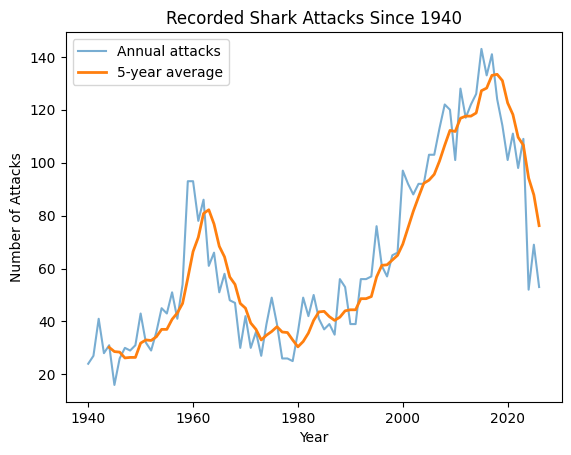

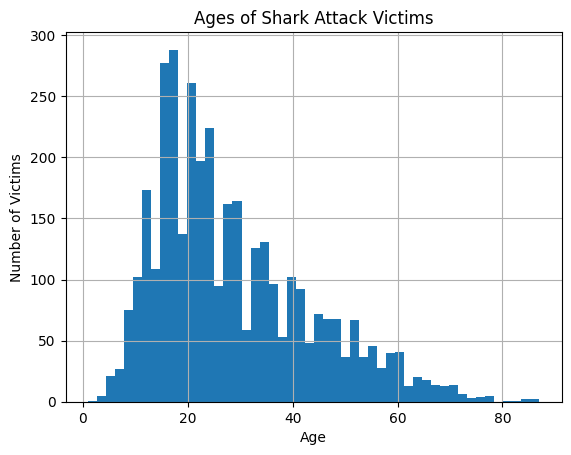

Proportion male: 0.8571707317073171
Proportion unprovoked: 0.7459236695932628


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

shark = pd.read_excel('/content/GSAF5.xls')

shark.head()

shark = shark.drop(
    columns=[
        'pdf',
        'href formula',
        'href',
        'Case Number',
        'Case Number.1',
        'original order',
        'Unnamed: 21',
        'Unnamed: 22'
    ]
)

shark['Year'] = pd.to_numeric(
    shark['Year'],
    errors='coerce'
)

shark['Year'] = shark['Year'].replace(0, np.nan)

print(shark['Year'].describe())

shark = shark[shark['Year'] >= 1940].copy()

attacks_per_year = shark['Year'].value_counts().sort_index()

attacks_per_year.plot(
    label='Annual attacks',
    alpha=0.6
)

attacks_per_year.rolling(5).mean().plot(
    label='5-year average',
    linewidth=2
)

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Recorded Shark Attacks Since 1940')
plt.legend()
plt.show()

shark['Age'] = pd.to_numeric(
    shark['Age'],
    errors='coerce'
)

shark['Age'].hist(bins=50)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Ages of Shark Attack Victims')
plt.show()

shark['Sex'] = shark['Sex'].str.strip().str.upper()

male_proportion = (
    (shark['Sex'] == 'M').sum()
    / shark['Sex'].isin(['M', 'F']).sum()
)

print("Proportion male:", male_proportion)

shark['Type'] = shark['Type'].str.strip().str.lower()

shark['Type'] = shark['Type'].replace({
    'provoked': 'Provoked',
    'unprovoked': 'Unprovoked'
})

shark.loc[
    ~shark['Type'].isin(['Provoked', 'Unprovoked']),
    'Type'
] = 'Unknown'

unprovoked_proportion = (
    (shark['Type'] == 'Unprovoked').sum()
    / len(shark)
)

print("Proportion unprovoked:", unprovoked_proportion)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Overall, my phase 2 use of AI was very productive. I felt like it gave me a huge advantage in fine tuning and structuring my code to make it more streamlined and correctly data cleaned. For example it helkped me fix my code to change the price varibale. It helped me rmeove inconsistencies and unnecesary steps like removed the importation of the numpy package. It also helped tell a better story with my data by advising me to add percentages and describing the year data in five year averages to shows it overall impact. It did have its limitations by trying to drop and change things I thought were effected and correct like the price as a float variable instead of the interger variable that I percieved to be better and more effective and I had to play with it in order to understand the assignment as well. In order to verify my solutions I reran each section and checked the data types and statitics that I was updating. I tried to be critical if I thought the move with AI was actually productive and if it was I maintained it in my code. I do have some remainign concers. I am not sure if I added too much data wrangling or too little, since I am still getting used to it. I also have a concern about the missingness in age. I feel like it could be important to the data, so increased data collection could be good when doing further shark analysis.